In [21]:
# setup
import sys

sys.path.insert(0, '...')

from src.config import load_parts_by_name, load_resource_lookup, load_part_lists
from src.genetic_algorithm import run_ga
from src.plots import plot_run
from datetime import datetime

parts_by_name = load_parts_by_name()
resource_lookup = load_resource_lookup()
pods, tanks, engines, decouplers = load_part_lists(parts_by_name)

In [22]:
# run
run_dir = f"../data/runs/run_{datetime.now().strftime('%Y-%m-%d-%H%M%S')}"

result = run_ga(
    n_rockets=100,
    n_generations=20,
    parts_by_name=parts_by_name,
    resource_lookup=resource_lookup,
    pods=pods,
    tanks=tanks,
    engines=engines,
    decouplers=decouplers,
    max_stages=5,
    n_elites=5,
    mutation_rate=0.3,
    detailed=True,
    save_dir=run_dir,
)

scores = [meta['score'] for _, meta in result]
print(f"best:    {max(scores):.0f} m/s")
print(f"mean:    {sum(scores) / len(scores):.0f} m/s")
print(f"nonzero: {sum(1 for s in scores if s > 0)}/{len(scores)}")

saved 100 rockets to ../data/runs/run_2026-04-03-145251/gen_000.json
saved 100 rockets to ../data/runs/run_2026-04-03-145251/gen_001.json
saved 100 rockets to ../data/runs/run_2026-04-03-145251/gen_002.json
saved 100 rockets to ../data/runs/run_2026-04-03-145251/gen_003.json
saved 100 rockets to ../data/runs/run_2026-04-03-145251/gen_004.json
saved 100 rockets to ../data/runs/run_2026-04-03-145251/gen_005.json
saved 100 rockets to ../data/runs/run_2026-04-03-145251/gen_006.json
saved 100 rockets to ../data/runs/run_2026-04-03-145251/gen_007.json
saved 100 rockets to ../data/runs/run_2026-04-03-145251/gen_008.json
saved 100 rockets to ../data/runs/run_2026-04-03-145251/gen_009.json
saved 100 rockets to ../data/runs/run_2026-04-03-145251/gen_010.json
saved 100 rockets to ../data/runs/run_2026-04-03-145251/gen_011.json
saved 100 rockets to ../data/runs/run_2026-04-03-145251/gen_012.json
saved 100 rockets to ../data/runs/run_2026-04-03-145251/gen_013.json
saved 100 rockets to ../data/runs/

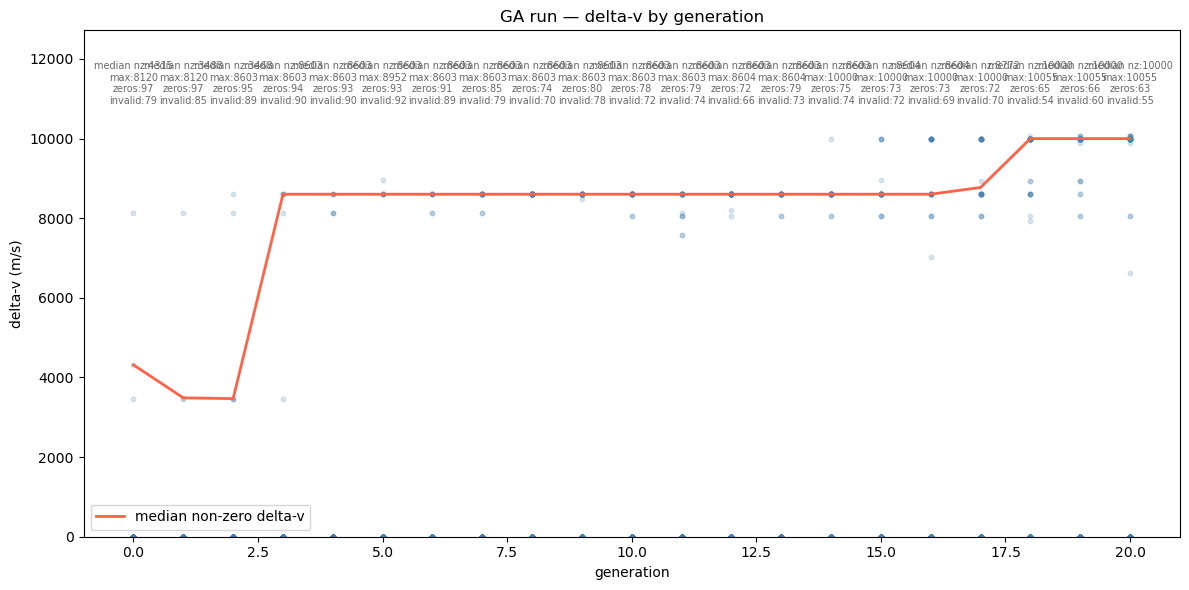

In [23]:
# plot
plot_run(run_dir)

In [24]:
# analyze
from src.analysis import analyze_population

analysis = analyze_population(result, top_n=10, verbose=True)

Top 10 mean score:  10,033 m/s  (2.76x population mean of 3,629 m/s)
Top 10 max score:   10,055 m/s  |  Pop max: 10,055 m/s
Pop zeros: 63.0%  |  Top zeros: 0.0%
Avg stages — top: 2.0  |  pop: 2.7
Top stage dist: 2-stage: 10
Avg parts  — top: 6.0  |  pop: 8.2
Top engine (top 10): liquidEngine3_v2 (10 uses)
Top tank   (top 10): Size3LargeTank (10 uses)
Top pod    (top 10): probeStackSmall (10 uses)


In [27]:
from src.analysis import inspect_top_rockets

inspect_top_rockets(
    "/Users/moss/Desktop/Personal_documents/repos/to_the_mun/data/runs/run_2026-04-03-145251",
    top_n=5,
)

file: /Users/moss/Desktop/Personal_documents/repos/to_the_mun/data/runs/run_2026-04-03-145251/gen_020.json
generation: 20

=== TOP 1 ===
score:    10054.7
engines:  ['liquidEngine3_v2', 'Size2LFB']
tanks:    ['Rockomax8BW', 'Size3LargeTank']
stages:   [0, 1]
stage_dv: {'1': 4864.976207583817, '0': 5189.73776663792}
parts:
  pod_0        probeStackSmall      parent=None         stage=None
  tank_0       Rockomax8BW          parent=pod_0        stage=None
  eng_0        liquidEngine3_v2     parent=tank_0       stage=0
  decoupler_0  Decoupler_0          parent=eng_0        stage=1
  tank_1       Size3LargeTank       parent=decoupler_0  stage=None
  eng_1        Size2LFB             parent=tank_1       stage=1

=== TOP 2 ===
score:    10054.7
engines:  ['liquidEngine3_v2', 'Size2LFB']
tanks:    ['Rockomax8BW', 'Size3LargeTank']
stages:   [0, 1]
stage_dv: {'1': 4864.976207583817, '0': 5189.73776663792}
parts:
  pod_0        probeStackSmall      parent=None         stage=None
  tank_0      

section to generate and plug into the harness

In [26]:
from pathlib import Path
from src.config import load_parts_by_name
from src.craft import to_craft

parts_by_name = load_parts_by_name()
test_rocket = {
    "parts": [
        {"id": "pod_0", "type": "probeCoreOcto_v2", "parent": None, "attach_node": None},
        {"id": "tank_0", "type": "adapterSize2-Size1", "parent": "pod_0", "attach_node": "bottom"},
        {"id": "eng_0", "type": "microEngine_v2", "parent": "tank_0", "attach_node": "bottom"},
        {"id": "decoupler_0", "type": "Decoupler_0", "parent": "eng_0", "attach_node": "bottom"},
        {"id": "tank_1", "type": "Size3SmallTank", "parent": "decoupler_0", "attach_node": "bottom"},
        {"id": "eng_1", "type": "Size2LFB_v2", "parent": "tank_1", "attach_node": "bottom"},
    ],
    "stages": {
        "eng_0": 0,
        "decoupler_0": 1,
        "eng_1": 1,
    }
}

craft_text, meta = to_craft(test_rocket, parts_by_name, ship_name="GeneratedTest")
print(meta)
out_path = Path("/Users/moss/Library/Application Support/Steam/steamapps/common/Kerbal Space Program/saves/MSandbox/Ships/VAB/GeneratedTest.craft")
out_path.write_text(craft_text)
print(out_path)

{'template_parts': ['probeCoreOcto_v2', 'microEngine_v2', 'Decoupler_0', 'Size3SmallTank'], 'fallback_parts': ['adapterSize2-Size1', 'Size2LFB_v2'], 'warnings': ['used generic fallback block for adapterSize2-Size1', 'used generic fallback block for Size2LFB_v2'], 'craft_part_names': {'pod_0': 'probeCoreOcto.v2', 'tank_0': 'adapterSize2-Size1', 'eng_0': 'microEngine.v2', 'decoupler_0': 'Decoupler.0', 'tank_1': 'Size3SmallTank', 'eng_1': 'Size2LFB.v2'}}
/Users/moss/Library/Application Support/Steam/steamapps/common/Kerbal Space Program/saves/MSandbox/Ships/VAB/GeneratedTest.craft
